Name : W. K. D. D. Senuruk  
## Blob Detection

#### Laplacian of Gaussian (LoG)

Applying laplacian operator on gaussian function,

$$
\nabla^2 = \frac{\partial^2}{\partial x^2} + \frac{\partial^2}{\partial y^2}
$$

Getting the second partial derivatives of the gaussian with respect to x and y, and then combining them to form the laplacian of the gaussian,

$$
\begin{aligned}
\frac{\partial^2 G}{\partial x^2}
&= \frac{\partial}{\partial x} \left[ G(x, y) \cdot \left( -\frac{x}{\sigma^2} \right) \right] = G(x, y) \cdot \left( \frac{x^2 - \sigma^2}{\sigma^4} \right)
\end{aligned}

\quad \quad \quad \quad \quad \quad

\begin{aligned}
\frac{\partial^2 G}{\partial x^2}
&= \frac{\partial}{\partial x} \left[ G(x, y) \cdot \left( -\frac{x}{\sigma^2} \right) \right] = G(x, y) \cdot \left( \frac{x^2 - \sigma^2}{\sigma^4} \right)
\end{aligned}
$$


$$
\text{LoG}(x, y) = \left( \frac{x^2 + y^2 - 2\sigma^2}{\sigma^4} \right) \cdot \frac{1}{2\pi\sigma^2} \cdot \exp\left( -\frac{x^2 + y^2}{2\sigma^2} \right)
$$

Scale-normalized laplacian of gaussian,

$$
\sigma^2 \nabla^2 G(x, y, \sigma)
$$

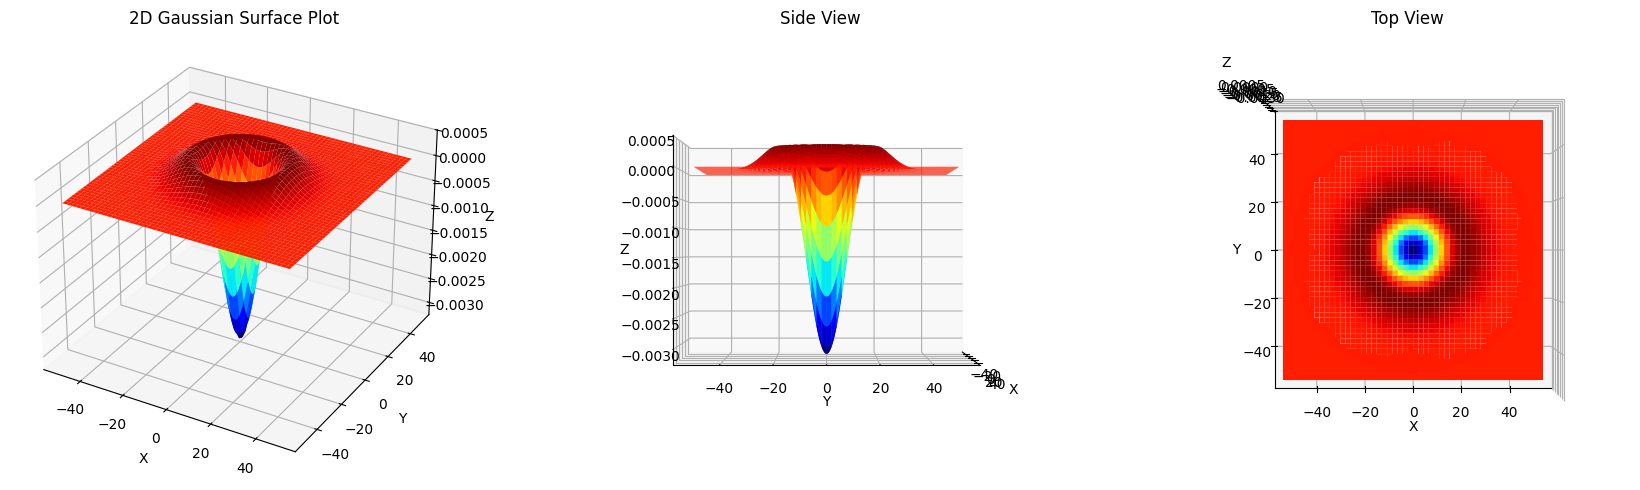

In [241]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

sigma = 10
spacial_resolution = 0.1
x = np.arange(-50, 50, spacial_resolution)
y = np.arange(-50, 50, spacial_resolution)
X, Y = np.meshgrid(x, y)
LoG = sigma**2 * ((X**2 + Y**2 - 2*sigma**2)/sigma**4)*(1/(2*np.pi*sigma**2))*np.exp(-(X**2+Y**2)/(2*sigma**2))

fig = plt.figure(figsize=(18, 5))

# main view
ax = fig.add_subplot(1, 3, 1, projection='3d')
surf = ax.plot_surface(X, Y, LoG, cmap='jet')
ax.set_title("2D Gaussian Surface Plot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# side view
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, LoG, cmap='jet')
ax2.view_init(elev=0, azim=0)  # side view from the x-direction
ax2.set_title("Side View")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")

# top view
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
surf3 = ax3.plot_surface(X, Y, LoG, cmap='jet')
ax3.view_init(elev=90, azim=-90)  # directly overhead
ax3.set_title("Top View")
ax3.set_xlabel("X")
ax3.set_ylabel("Y")
ax3.set_zlabel("Z")

plt.tight_layout()
plt.show()

#### Filtering images with LoG kernals

Creating an image of a black circle of radius 14

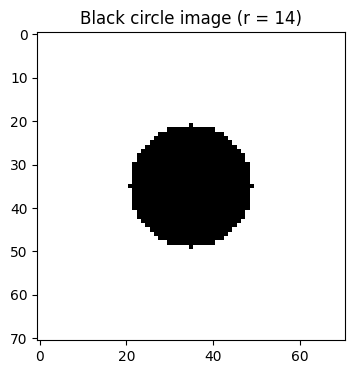

In [242]:
w, h = 71, 71
wc, hc = w//2, h//2
r = 14

x = np.arange(-wc, wc+1, 1)
y = np.arange(-hc, hc+1, 1)
X, Y = np.meshgrid(x, y)

image = np.ones((h, w), dtype=np.float32) * 255
image *= X**2 +Y**2 > r**2
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
plt.title("Black circle image (r = 14)")
plt.show()

Let's filter the black circle image with a series of LoG kernals to find the scale-space extremum

Maximum response across all scales of sigma...
Pixel y : 35 ,    Pixel x : 35 ,    Sigma value : 10


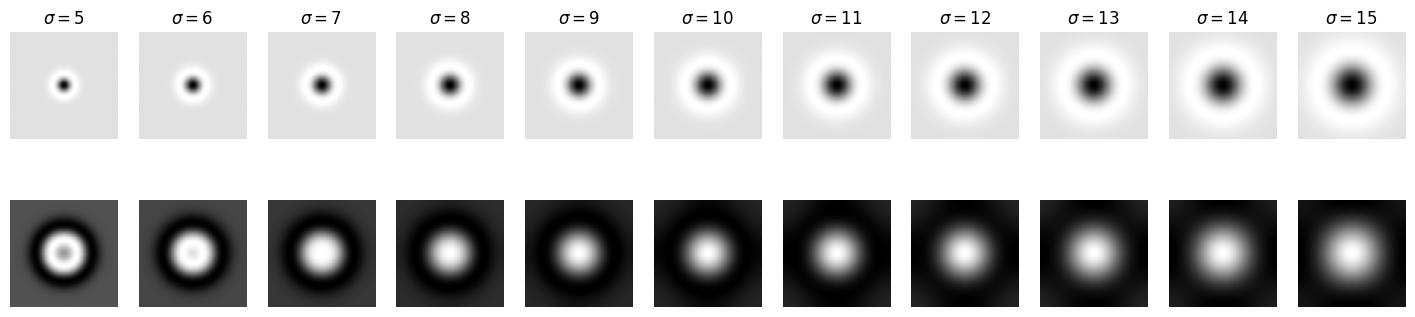

In [243]:
import cv2 as cv

s = 11
sigma = np.arange(5, 16, 1)
scale_space = np.empty((h, w, s), dtype=np.float32)

fig, ax = plt.subplots(2, 11, figsize=(18, 4))
for i in range(sigma.shape[0]):
    sigma_ = sigma[i]
    LoG_hw = 3*np.max(sigma)

    x = np.arange(-LoG_hw, LoG_hw+1, 1)
    y = np.arange(-LoG_hw, LoG_hw+1, 1)
    X, Y = np.meshgrid(x, y)
    LoG = sigma_**2 * ((X**2 + Y**2 - 2*sigma_**2)/sigma_**4)*(1/(2*np.pi*sigma_**2))*np.exp(-(X**2+Y**2)/(2*sigma_**2))
    image_LoG = cv.filter2D(image, -1, LoG)
    scale_space[:, :, i] = image_LoG

    ax[0, i].imshow(LoG, cmap="gray")
    ax[0, i].set_title('$\\sigma = {}$'.format(sigma_))
    ax[0, i].axis("off")
    ax[1, i].imshow(image_LoG, cmap="gray")
    ax[1, i].axis("off")

indices = np.unravel_index(np.argmax(scale_space, axis=None), scale_space.shape)
print("Maximum response across all scales of sigma...")
print("Pixel y :", indices[0], ",    Pixel x :", indices[1], ",    Sigma value :", sigma[indices[2]])

#### Blob detection using OpenCV's existing functionality

Number of detected blobs: 44


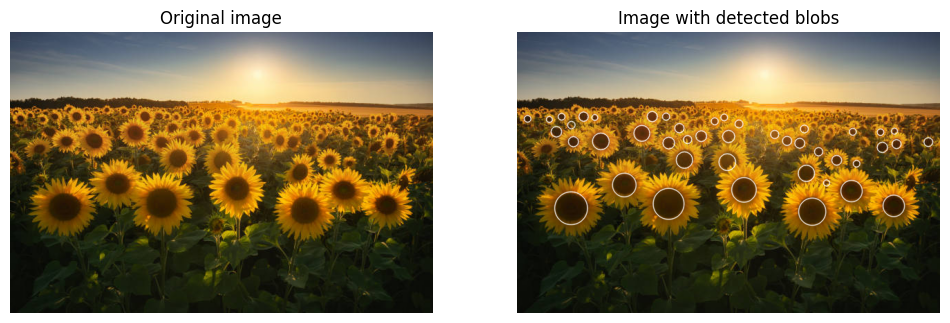

In [244]:
image_color = cv.imread(r'./Images/sun_flower_field_1.jpg', cv.IMREAD_COLOR)
image = cv.cvtColor(image_color, cv.COLOR_BGR2GRAY)

# Set up the detector with default parameters
params = cv.SimpleBlobDetector_Params()

# Optional: tweak parameters to fit your case
params.filterByArea = True
params.minArea = 50
params.filterByCircularity = True
params.minCircularity = 0.2
params.filterByConvexity = True
params.minConvexity = 0.8
params.filterByInertia = True
params.minInertiaRatio = 0.3

# Creating detector, detecting blobs aand drawing detected blobs
detector = cv.SimpleBlobDetector_create(params)
keypoints = detector.detect(image)
output = cv.drawKeypoints(image_color, keypoints, np.array([]), (255,255,255),
                           cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

print(f"Number of detected blobs: {len(keypoints)}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(cv.cvtColor(image_color, cv.COLOR_BGR2RGB))
ax[0].set_title("Original image")
ax[0].axis("off")
ax[1].imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
ax[1].set_title("Image with detected blobs")
ax[1].axis("off")
plt.show()


#### Analyzing blob detection

This is just an analyzation to observe the cross correlation between various kernels and the image  
Here, we can observe the filtered images with the change of the standard diviation of the LoG kernel

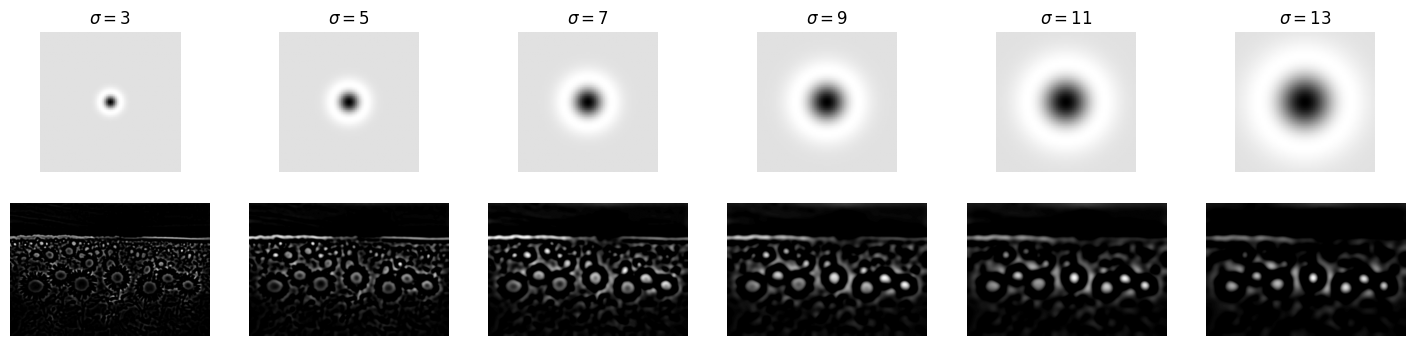

In [245]:
s = 11
sigma = np.arange(3, 14, 2)

fig, ax = plt.subplots(2, sigma.shape[0], figsize=(18, 4))
for i in range(sigma.shape[0]):
    sigma_ = sigma[i]
    LoG_hw = 3*np.max(sigma)

    x = np.arange(-LoG_hw, LoG_hw+1, 1)
    y = np.arange(-LoG_hw, LoG_hw+1, 1)
    X, Y = np.meshgrid(x, y)
    LoG = sigma_**2 * ((X**2 + Y**2 - 2*sigma_**2)/sigma_**4)*(1/(2*np.pi*sigma_**2))*np.exp(-(X**2+Y**2)/(2*sigma_**2))
    image_LoG = cv.filter2D(image, -1, LoG)

    ax[0, i].imshow(LoG, cmap="gray")
    ax[0, i].set_title('$\\sigma = {}$'.format(sigma_))
    ax[0, i].axis("off")
    ax[1, i].imshow(image_LoG, cmap="gray")

    ax[1, i].axis("off")

#### My own implementation for blob detection

Image is cross-correlated with the LoG kernel in different values of sigma

$$
R(x, y, \sigma) = I(x, y) * \text{LoG}(x, y, \sigma)
$$

This creates a 3D scale-space volume across different sigma values  
For the non-maximum suppression in scale-space, local maxima in 3D scale-space are extracted using a maximum filter  
Then, thresholding is applied

$$
R(x, y, \sigma) > T
$$

Where T is the threshold calculated as a high percentile (e.g., 99.5th) of all scale-space values  
For a detected blob at scale sigma, the corresponding radius is estimated as,

$$
r = \sqrt{2} \cdot \sigma
$$


Number of detected blobs: 37


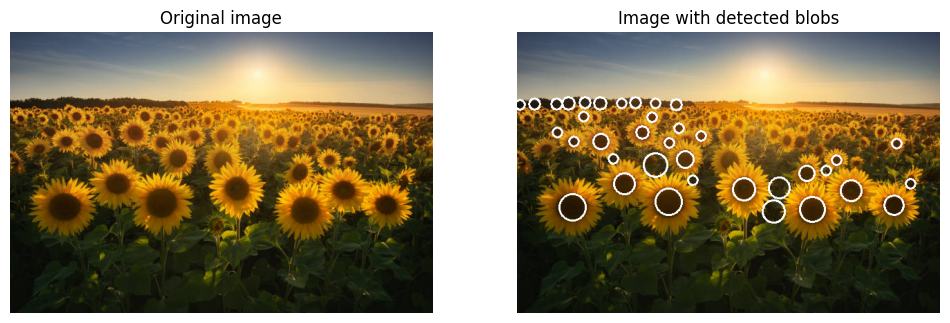

In [246]:
from scipy.ndimage import maximum_filter
import math

sigma_g = 0
image_ = cv.GaussianBlur(image, (5, 5), sigma_g).astype(np.float32)
#image_ = image.astype(np.float32)

sigma = np.arange(5, 15, 0.5)
s = sigma.shape[0]
h, w = image.shape
scale_space = np.empty((h, w, s), dtype=np.float32)

for i in range(sigma.shape[0]):
    sigma_ = sigma[i]
    LoG_hw = 3*sigma_

    x = np.arange(-LoG_hw, LoG_hw+1, 1)
    y = np.arange(-LoG_hw, LoG_hw+1, 1)
    X, Y = np.meshgrid(x, y)
    LoG = sigma_**2 * ((X**2 + Y**2 - 2*sigma_**2)/sigma_**4)*(1/(2*np.pi*sigma_**2))*np.exp(-(X**2+Y**2)/(2*sigma_**2))
    image_LoG = cv.filter2D(image.astype(np.float32), -1, LoG, borderType=cv.BORDER_REPLICATE).astype(np.float32)
    # squared_image_LoG = image_LoG**2
    scale_space[:, :, i] = image_LoG

threshold = np.percentile(scale_space, 99.5)
local_max = maximum_filter(scale_space, size=(21, 21, 3))
blobs = (scale_space == local_max) & (scale_space > threshold)

blob_list = []
for y, x, k in zip(*np.where(blobs)):
    sigma_ = sigma[k]
    radius = np.sqrt(2) * sigma_
    blob_list.append((x, y, radius))

image_with_blobs = image_color.copy()
for x, y, r in blob_list:
    cv.circle(image_with_blobs, (int(x), int(y)), int(r), (255, 255, 255), 2)

print(f"Number of detected blobs: {len(blob_list)}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(cv.cvtColor(image_color, cv.COLOR_BGR2RGB))
ax[0].set_title("Original image")
ax[0].axis("off")
ax[1].imshow(cv.cvtColor(image_with_blobs, cv.COLOR_BGR2RGB))
ax[1].set_title("Image with detected blobs")
ax[1].axis("off")
plt.show()